# Data Exploration Debug Notebook

This notebook breaks down the data exploration script into small chunks with debug code to help you understand what's happening at each step.

## Overview
We'll process TSV files containing module completeness data and create a heatmap visualization.

## 1. Import Libraries
First, let's import all the necessary libraries and print their versions for debugging.

In [40]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import traceback

# Debug: Print library versions
print("Library versions:")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print("\nAll libraries imported successfully!")

Library versions:
pandas: 2.2.3
matplotlib: 3.10.3
seaborn: 0.13.2

All libraries imported successfully!


## 2. Locate and List TSV Files
Let's find all TSV files in the directory and see what we're working with.

In [41]:
# Define the directory path
data_dir = "C:/Users/mlazar/Desktop/heatmapper_script/"
print(f"Looking for TSV files in: {data_dir}")

# Find all TSV files
tsv_files = glob.glob(data_dir + "*.tsv")

# Debug output
print(f"\nFound {len(tsv_files)} TSV files:")
for i, file in enumerate(tsv_files, 1):
    filename = os.path.basename(file)
    file_size = os.path.getsize(file)
    print(f"  {i}. {filename} ({file_size:,} bytes)")

if len(tsv_files) == 0:
    print("No TSV files found! Check the directory path.")
else:
    print(f"\n Ready to process {len(tsv_files)} files")

Looking for TSV files in: C:/Users/mlazar/Desktop/heatmapper_script/

Found 6 TSV files:
  1. Oleococcus.tsv (20,477 bytes)
  2. Palaeococcus.tsv (25,750 bytes)
  3. Piezococcus.tsv (21,511 bytes)
  4. Pyrococcus.tsv (19,646 bytes)
  5. Thermococcales.tsv (17,296 bytes)
  6. Thermococcus.tsv (17,848 bytes)

 Ready to process 6 files


## 3. Load and Process Individual TSV Files
Now let's load each TSV file and examine its structure before processing.

In [42]:
dfs = []

for i, file_path in enumerate(tsv_files, 1):
    print(f"\n{'='*50}")
    print(f"Processing file {i}/{len(tsv_files)}: {os.path.basename(file_path)}")
    print(f"{'='*50}")
    
    try:
        # Load the TSV file
        df = pd.read_csv(file_path, sep="\t")
        
        # Debug: Show original structure
        print(f"Original shape: {df.shape} (rows, columns)")
        print(f"Columns: {list(df.columns)}")
        
        # Extract sample name from filename
        sample_name = os.path.splitext(os.path.basename(file_path))[0]
        print(f"Sample name: '{sample_name}'")
        
        # Add sample column
        df["sample"] = sample_name
        
        # Process pathway_name column if it exists
        if 'pathway_name' in df.columns:
            print(f"\nOriginal pathway_name examples:")
            print(df['pathway_name'].head(3).tolist())
            
            # Truncate pathway_name to text before first comma
            df['pathway_name'] = df['pathway_name'].apply(lambda x: str(x).split(',')[0].strip())
            
            print(f"\nTruncated pathway_name examples:")
            print(df['pathway_name'].head(3).tolist())
        else:
            print("  'pathway_name' column not found!")
        
        # Debug: Show final structure
        print(f"\nFinal shape: {df.shape}")
        print(f"\nFirst few rows:")
        print(df.head(2))
        
        # Check for key columns
        required_cols = ['module', 'pathway_name', 'completeness']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            print(f"  Missing required columns: {missing_cols}")
        else:
            print(f" All required columns present: {required_cols}")
        
        dfs.append(df)
        print(f" Successfully processed: {os.path.basename(file_path)}")
        
    except Exception as e:
        print(f" Error processing {file_path}: {str(e)}")
        print(traceback.format_exc())

print(f"\n{'='*60}")
print(f"SUMMARY: Successfully loaded {len(dfs)} out of {len(tsv_files)} files")
print(f"{'='*60}")


Processing file 1/6: Oleococcus.tsv
Original shape: (112, 6) (rows, columns)
Columns: ['module_accession', 'completeness', 'pathway_name', 'pathway_class', 'matching_ko', 'missing_ko']
Sample name: 'Oleococcus'

Original pathway_name examples:
['Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate', 'Glycolysis, core module involving three-carbon compounds', 'Gluconeogenesis, oxaloacetate => fructose-6P']

Truncated pathway_name examples:
['Glycolysis (Embden-Meyerhof pathway)', 'Glycolysis', 'Gluconeogenesis']

Final shape: (112, 7)

First few rows:
  module_accession  completeness                          pathway_name  \
0           M00001         100.0  Glycolysis (Embden-Meyerhof pathway)   
1           M00002         100.0                            Glycolysis   

                                       pathway_class  \
0  Pathway modules; Carbohydrate metabolism; Cent...   
1  Pathway modules; Carbohydrate metabolism; Cent...   

                                         matc

## 4. Combine DataFrames
Now let's combine all individual DataFrames into one master DataFrame.

In [43]:
if len(dfs) == 0:
    print("❌ No DataFrames to combine!")
else:
    print("Combining DataFrames...")
    
    # Show individual DataFrame shapes before combining
    print(f"\nIndividual DataFrame shapes:")
    total_rows = 0
    for i, df in enumerate(dfs):
        sample_name = df['sample'].iloc[0]
        print(f"  {sample_name}: {df.shape}")
        total_rows += df.shape[0]
    
    print(f"\nExpected total rows after combining: {total_rows}")
    
    # Combine all dataframes
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Debug: Show combined results
    print(f"\nActual combined shape: {combined_df.shape}")
    print(f"Columns in combined DataFrame: {list(combined_df.columns)}")
    
    # Check sample distribution
    print(f"\nSample distribution:")
    sample_counts = combined_df['sample'].value_counts()
    print(sample_counts)
    
    # Show data types
    print(f"\nData types:")
    print(combined_df.dtypes)
    
    # Show first few rows
    print(f"\nFirst 3 rows of combined data:")
    print(combined_df.head(3))
    
    # Check for missing values
    print(f"\nMissing values per column:")
    missing_values = combined_df.isnull().sum()
    print(missing_values[missing_values > 0])
    
    if missing_values.sum() == 0:
        print("No missing values found!")

    print(f"\n Successfully combined {len(dfs)} DataFrames")

Combining DataFrames...

Individual DataFrame shapes:
  Oleococcus: (112, 7)
  Palaeococcus: (140, 7)
  Piezococcus: (119, 7)
  Pyrococcus: (107, 7)
  Thermococcales: (94, 7)
  Thermococcus: (97, 7)

Expected total rows after combining: 669

Actual combined shape: (669, 7)
Columns in combined DataFrame: ['module_accession', 'completeness', 'pathway_name', 'pathway_class', 'matching_ko', 'missing_ko', 'sample']

Sample distribution:
sample
Palaeococcus      140
Piezococcus       119
Oleococcus        112
Pyrococcus        107
Thermococcus       97
Thermococcales     94
Name: count, dtype: int64

Data types:
module_accession     object
completeness        float64
pathway_name         object
pathway_class        object
matching_ko          object
missing_ko           object
sample               object
dtype: object

First 3 rows of combined data:
  module_accession  completeness                          pathway_name  \
0           M00001         100.0  Glycolysis (Embden-Meyerhof pathway)

## 5. Create Unique Identifiers
Let's create a unique identifier by combining module and pathway information.

In [44]:
if 'combined_df' in locals():
    print("Creating unique module identifiers...")
    
    # Show original module and pathway_name examples
    print(f"\nOriginal 'module' examples:")
    print(combined_df['module_accession'].head(3).tolist())
    
    print(f"\nOriginal 'pathway_name' examples:")
    print(combined_df['pathway_name'].head(3).tolist())
    
    # Create the unique identifier
    combined_df['module_info'] = combined_df['module_accession'] + ': ' + combined_df['pathway_name']
    
    # Debug: Show the new column
    print(f"\nNew 'module_info' examples:")
    print(combined_df['module_info'].head(5).tolist())
    
    # Check for duplicates
    print(f"\nUnique modules: {combined_df['module_accession'].nunique()}")
    print(f"Unique pathway names: {combined_df['pathway_name'].nunique()}")
    print(f"Unique module_info combinations: {combined_df['module_info'].nunique()}")
    
    # Show updated DataFrame structure
    print(f"\nUpdated DataFrame shape: {combined_df.shape}")
    print(f"Updated columns: {list(combined_df.columns)}")
    
    # Show sample of the data with new column
    print(f"\nSample data with module_info:")
    print(combined_df[['module_accession', 'pathway_name', 'module_info', 'sample', 'completeness']].head(3))
    
    print(f"\n Module identifiers created successfully!")
else:
    print("combined_df not available. Run previous cells first.")

Creating unique module identifiers...

Original 'module' examples:
['M00001', 'M00002', 'M00003']

Original 'pathway_name' examples:
['Glycolysis (Embden-Meyerhof pathway)', 'Glycolysis', 'Gluconeogenesis']

New 'module_info' examples:
['M00001: Glycolysis (Embden-Meyerhof pathway)', 'M00002: Glycolysis', 'M00003: Gluconeogenesis', 'M00005: PRPP biosynthesis', 'M00048: De novo purine biosynthesis']

Unique modules: 149
Unique pathway names: 111
Unique module_info combinations: 149

Updated DataFrame shape: (669, 8)
Updated columns: ['module_accession', 'completeness', 'pathway_name', 'pathway_class', 'matching_ko', 'missing_ko', 'sample', 'module_info']

Sample data with module_info:
  module_accession                          pathway_name  \
0           M00001  Glycolysis (Embden-Meyerhof pathway)   
1           M00002                            Glycolysis   
2           M00003                       Gluconeogenesis   

                                    module_info      sample  compl

## 6. Generate Pivot Table
Now let's create a pivot table to organize the data for heatmap visualization.

In [45]:
if 'combined_df' in locals() and 'module_info' in combined_df.columns:
    print("Creating pivot table...")
    
    # Show data before pivoting
    print(f"\nData before pivoting:")
    print(f"  Rows: {combined_df.shape[0]}")
    print(f"  Unique module_info: {combined_df['module_info'].nunique()}")
    print(f"  Unique samples: {combined_df['sample'].nunique()}")
    print(f"  Sample names: {combined_df['sample'].unique().tolist()}")
    
    # Check completeness values
    print(f"\nCompleteness statistics:")
    print(combined_df['completeness'].describe())
    
    # Create the pivot table
    print(f"\nCreating pivot table...")
    pivot_df = combined_df.pivot_table(
        index='module_info',
        columns='sample',
        values='completeness'
    )
    
    # Debug: Show pivot table info
    print(f"\nPivot table created!")
    print(f"Shape: {pivot_df.shape} (modules × samples)")
    print(f"Index (modules): {len(pivot_df.index)}")
    print(f"Columns (samples): {len(pivot_df.columns)}")
    print(f"Column names: {list(pivot_df.columns)}")
    
    # Check for missing values in pivot
    missing_in_pivot = pivot_df.isnull().sum().sum()
    print(f"Missing values in pivot table: {missing_in_pivot}")
    
    if missing_in_pivot > 0:
        print(f"Missing values per sample:")
        print(pivot_df.isnull().sum())
    
    # Show first few rows and columns
    print(f"\nFirst 3 modules and all samples:")
    print(pivot_df.head(3))
    
    # Show data range
    print(f"\nData range in pivot table:")
    print(f"  Minimum: {pivot_df.min().min():.2f}")
    print(f"  Maximum: {pivot_df.max().max():.2f}")
    print(f"  Mean: {pivot_df.mean().mean():.2f}")
    
    print(f"\n Pivot table created successfully!")
else:
    print("Required data not available. Run previous cells first.")

Creating pivot table...

Data before pivoting:
  Rows: 669
  Unique module_info: 149
  Unique samples: 6
  Sample names: ['Oleococcus', 'Palaeococcus', 'Piezococcus', 'Pyrococcus', 'Thermococcales', 'Thermococcus']

Completeness statistics:
count    669.000000
mean      45.025366
std       30.254452
min        1.250000
25%       20.000000
50%       33.330000
75%       66.670000
max      100.000000
Name: completeness, dtype: float64

Creating pivot table...

Pivot table created!
Shape: (149, 6) (modules × samples)
Index (modules): 149
Columns (samples): 6
Column names: ['Oleococcus', 'Palaeococcus', 'Piezococcus', 'Pyrococcus', 'Thermococcales', 'Thermococcus']
Missing values in pivot table: 225
Missing values per sample:
sample
Oleococcus        37
Palaeococcus       9
Piezococcus       30
Pyrococcus        42
Thermococcales    55
Thermococcus      52
dtype: int64

First 3 modules and all samples:
sample                                        Oleococcus  Palaeococcus  \
module_info    

## 7. Sort Pivot Table
Let's sort the modules by their mean completeness values for better visualization.

In [46]:
if 'pivot_df' in locals():
    print("Sorting pivot table by mean completeness...")
    
    # Calculate mean completeness for each module
    mean_completeness = pivot_df.mean(axis=1)
    print(f"\nMean completeness statistics:")
    print(mean_completeness.describe())
    
    # Show top and bottom modules before sorting
    print(f"\nTop 5 modules by mean completeness (before sorting):")
    top_modules = mean_completeness.nlargest(5)
    print(top_modules)
    
    print(f"\nBottom 5 modules by mean completeness (before sorting):")
    bottom_modules = mean_completeness.nsmallest(5)
    print(bottom_modules)
    
    # Sort the pivot table
    pivot_df_sorted = pivot_df.reindex(mean_completeness.sort_values(ascending=False).index)
    
    # Debug: Verify sorting
    print(f"\nSorting verification:")
    print(f"Original pivot shape: {pivot_df.shape}")
    print(f"Sorted pivot shape: {pivot_df_sorted.shape}")
    
    # Show that the order has changed
    print(f"\nFirst 5 modules after sorting:")
    sorted_means = pivot_df_sorted.mean(axis=1).head(5)
    print(sorted_means)
    
    print(f"\nLast 5 modules after sorting:")
    sorted_means_bottom = pivot_df_sorted.mean(axis=1).tail(5)
    print(sorted_means_bottom)
    
    # Update the pivot_df variable
    pivot_df = pivot_df_sorted
    
    print(f"\n✅ Pivot table sorted successfully (highest to lowest completeness)!")
else:
    print("❌ pivot_df not available. Run previous cells first.")

Sorting pivot table by mean completeness...

Mean completeness statistics:
count    149.000000
mean      41.953579
std       29.005295
min        1.250000
25%       19.446667
50%       33.330000
75%       58.335000
max      100.000000
dtype: float64

Top 5 modules by mean completeness (before sorting):
module_info
M00001: Glycolysis (Embden-Meyerhof pathway)    100.0
M00002: Glycolysis                              100.0
M00003: Gluconeogenesis                         100.0
M00005: PRPP biosynthesis                       100.0
M00049: Adenine ribonucleotide biosynthesis     100.0
dtype: float64

Bottom 5 modules by mean completeness (before sorting):
module_info
M00567: Methanogenesis            1.25
M00357: Methanogenesis            2.00
M00563: Methanogenesis            2.50
M00925: Cobalamin biosynthesis    3.03
M00356: Methanogenesis            3.33
dtype: float64

Sorting verification:
Original pivot shape: (149, 6)
Sorted pivot shape: (149, 6)

First 5 modules after sorting:
modul

## 8. Visualize Heatmap
Now let's create the heatmap visualization with all the formatting options.

Creating heatmap visualization...

Heatmap dimensions:
  Modules (rows): 149
  Samples (columns): 6
  Calculated figure size: 12 × 44.7 inches

Data range for color mapping:
  Actual min: 1.25
  Actual max: 100.00
  Color scale: 0 to 100

Generating heatmap...

Heatmap statistics:
  Cells with data: 669
  Cells with missing data: 225
  Cells with 0% completeness: 0
  Cells with 100% completeness: 104


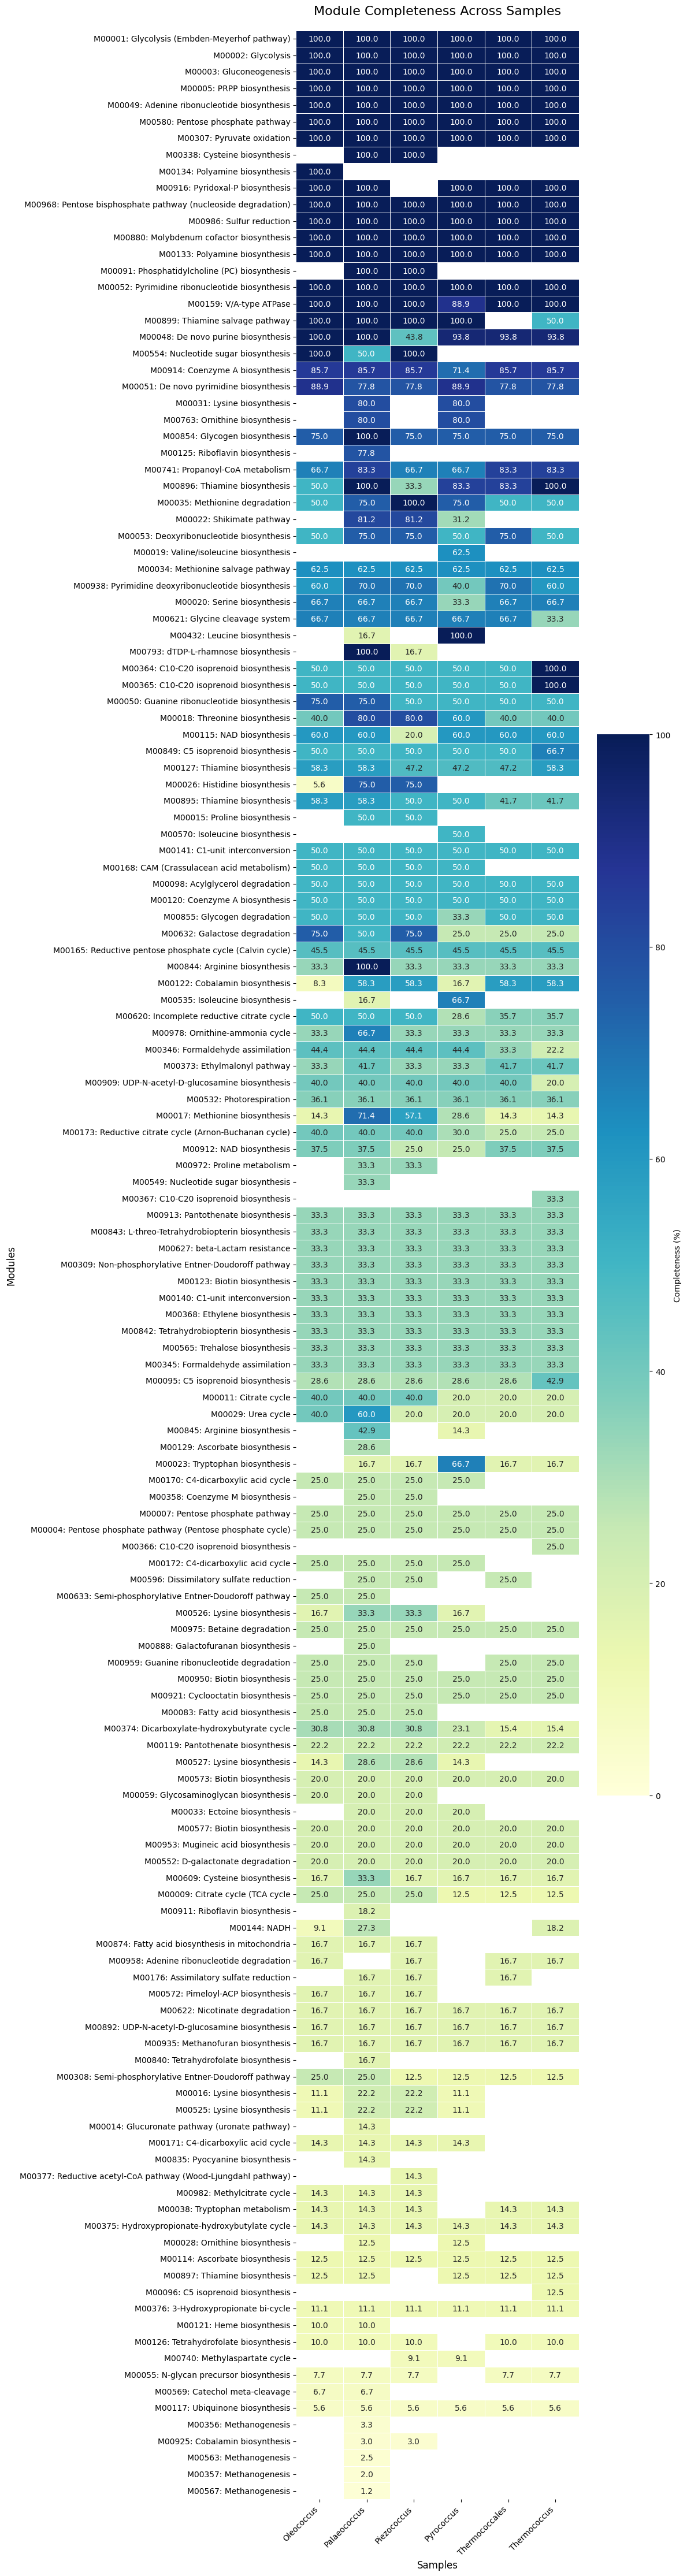


 Heatmap visualization created successfully!


In [47]:
if 'pivot_df' in locals():
    print("Creating heatmap visualization...")
    
    # Debug: Show heatmap dimensions
    n_modules = len(pivot_df)
    n_samples = len(pivot_df.columns)
    print(f"\nHeatmap dimensions:")
    print(f"  Modules (rows): {n_modules}")
    print(f"  Samples (columns): {n_samples}")
    
    # Calculate figure size
    fig_width = 12
    fig_height = n_modules * 0.3
    print(f"  Calculated figure size: {fig_width} × {fig_height:.1f} inches")
    
    # Create the figure
    plt.figure(figsize=(fig_width, fig_height))
    
    # Debug: Data range for color mapping
    data_min = pivot_df.min().min()
    data_max = pivot_df.max().max()
    print(f"\nData range for color mapping:")
    print(f"  Actual min: {data_min:.2f}")
    print(f"  Actual max: {data_max:.2f}")
    print(f"  Color scale: 0 to 100")
    
    # Create heatmap
    print(f"\nGenerating heatmap...")
    heatmap = sns.heatmap(
        pivot_df, 
        annot=True,            # Show values in cells
        fmt=".1f",             # Format numbers to 1 decimal place
        cmap="YlGnBu",         # Blue-green-yellow colormap
        linewidths=0.5,        # Add grid lines
        vmin=0,                # Minimum value (0%)
        vmax=100,              # Maximum value (100%)
        cbar_kws={'label': 'Completeness (%)'}  # Add label to color bar
    )
    
    # Add titles and labels
    plt.title("Module Completeness Across Samples", fontsize=16, pad=20)
    plt.ylabel("Modules", fontsize=12)
    plt.xlabel("Samples", fontsize=12)
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    # Adjust layout
    plt.tight_layout()
    
    # Debug: Print some statistics about what's displayed
    print(f"\nHeatmap statistics:")
    print(f"  Cells with data: {(~pivot_df.isnull()).sum().sum()}")
    print(f"  Cells with missing data: {pivot_df.isnull().sum().sum()}")
    print(f"  Cells with 0% completeness: {(pivot_df == 0).sum().sum()}")
    print(f"  Cells with 100% completeness: {(pivot_df == 100).sum().sum()}")
    
    # Show the plot
    plt.show()
    
    print(f"\n Heatmap visualization created successfully!")
else:
    print(" pivot_df not available. Run previous cells first.")

## 9. Save Outputs
Finally, let's save our results to files for future use.

In [48]:
if 'pivot_df' in locals():
    print("Saving outputs...")
    
    # Save the heatmap image
    plt.figure(figsize=(12, len(pivot_df) * 0.3))
    
    # Recreate the heatmap for saving
    sns.heatmap(
        pivot_df, 
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5,
        vmin=0,
        vmax=100,
        cbar_kws={'label': 'Completeness (%)'}
    )
    
    plt.title("Module Completeness Across Samples")
    plt.ylabel("Modules")
    plt.xlabel("Samples")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save the figure
    image_filename = "module_completeness_heatmap.png"
    plt.savefig(image_filename, dpi=300, bbox_inches='tight')
    plt.close()  # Close to free memory
    
    # Check if file was saved
    if os.path.exists(image_filename):
        file_size = os.path.getsize(image_filename)
        print(f"✅ Heatmap saved as '{image_filename}' ({file_size:,} bytes)")
    else:
        print(f"❌ Failed to save heatmap image")
    
    # Save the pivot table as CSV
    csv_filename = "heatmap_data.csv"
    pivot_df.to_csv(csv_filename)
    
    # Check if CSV was saved
    if os.path.exists(csv_filename):
        file_size = os.path.getsize(csv_filename)
        print(f"✅ Heatmap data saved as '{csv_filename}' ({file_size:,} bytes)")
        
        # Show CSV structure
        print(f"\nCSV file structure:")
        csv_check = pd.read_csv(csv_filename, index_col=0)
        print(f"  Shape: {csv_check.shape}")
        print(f"  Index name: {csv_check.index.name}")
        print(f"  Column names: {list(csv_check.columns)}")
    else:
        print(f"❌ Failed to save CSV file")
    
    # Summary of all outputs
    print(f"\n{'='*50}")
    print(f"FINAL SUMMARY")
    print(f"{'='*50}")
    print(f"📊 Processed {len(dfs)} TSV files")
    print(f"🔢 Combined data shape: {combined_df.shape}")
    print(f"📋 Pivot table shape: {pivot_df.shape}")
    print(f"🎨 Heatmap saved: {image_filename}")
    print(f"💾 Data saved: {csv_filename}")
    print(f"✅ All tasks completed successfully!")
    
else:
    print("❌ pivot_df not available. Run all previous cells first.")

Saving outputs...
✅ Heatmap saved as 'module_completeness_heatmap.png' (2,942,198 bytes)
✅ Heatmap data saved as 'heatmap_data.csv' (9,324 bytes)

CSV file structure:
  Shape: (149, 6)
  Index name: module_info
  Column names: ['Oleococcus', 'Palaeococcus', 'Piezococcus', 'Pyrococcus', 'Thermococcales', 'Thermococcus']

FINAL SUMMARY
📊 Processed 6 TSV files
🔢 Combined data shape: (669, 8)
📋 Pivot table shape: (149, 6)
🎨 Heatmap saved: module_completeness_heatmap.png
💾 Data saved: heatmap_data.csv
✅ All tasks completed successfully!


## 10. Create Metabolism-Specific Heatmaps
Let's create separate heatmaps for different types of metabolism based on the pathway_class information.

In [49]:
if 'combined_df' in locals():
    print("Analyzing pathway classes for metabolism types...")
    
    # Examine the pathway_class structure
    print(f"\nUnique pathway classes:")
    unique_classes = combined_df['pathway_class'].unique()
    for i, cls in enumerate(unique_classes[:10], 1):  # Show first 10
        print(f"  {i}. {cls}")
    
    if len(unique_classes) > 10:
        print(f"  ... and {len(unique_classes) - 10} more")
    
    # Extract metabolism types from pathway_class
    print(f"\nExtracting metabolism types...")
    
    def extract_metabolism_type(pathway_class):
        """Extract the main metabolism type from pathway_class"""
        if pd.isna(pathway_class):
            return 'Unknown'
        
        parts = str(pathway_class).split(';')
        if len(parts) >= 2:
            metabolism_type = parts[1].strip()
            return metabolism_type
        return 'Other'
    
    # Add metabolism type column
    combined_df['metabolism_type'] = combined_df['pathway_class'].apply(extract_metabolism_type)
    
    # Show metabolism type distribution
    print(f"\nMetabolism types found:")
    metabolism_counts = combined_df['metabolism_type'].value_counts()
    print(metabolism_counts)
    
    print(f"\n✅ Metabolism types extracted successfully!")
else:
    print("❌ combined_df not available. Run previous cells first.")

Analyzing pathway classes for metabolism types...

Unique pathway classes:
  1. Pathway modules; Carbohydrate metabolism; Central carbohydrate metabolism
  2. Pathway modules; Nucleotide metabolism; Purine metabolism
  3. Pathway modules; Nucleotide metabolism; Pyrimidine metabolism
  4. Pathway modules; Amino acid metabolism; Polyamine biosynthesis
  5. Pathway modules; Energy metabolism; ATP synthesis
  6. Pathway modules; Carbohydrate metabolism; Other carbohydrate metabolism
  7. Pathway modules; Metabolism of cofactors and vitamins; Cofactor and vitamin metabolism
  8. Pathway modules; Energy metabolism; Sulfur metabolism
  9. Pathway modules; Amino acid metabolism; Serine and threonine metabolism
  10. Pathway modules; Amino acid metabolism; Cysteine and methionine metabolism
  ... and 18 more

Extracting metabolism types...

Metabolism types found:
metabolism_type
Carbohydrate metabolism                        157
Metabolism of cofactors and vitamins           156
Amino acid met

In [50]:
if 'combined_df' in locals() and 'metabolism_type' in combined_df.columns:
    print("Creating separate pivot tables for each metabolism type...")
    
    # Get unique metabolism types (excluding 'Unknown' and very small groups)
    metabolism_types = combined_df['metabolism_type'].value_counts()
    print(f"\nMetabolism types with module counts:")
    for met_type, count in metabolism_types.items():
        print(f"  {met_type}: {count} modules")
    
    # Filter to metabolism types with at least 3 modules for meaningful heatmaps
    significant_types = metabolism_types[metabolism_types >= 3].index.tolist()
    print(f"\nCreating heatmaps for {len(significant_types)} metabolism types with ≥3 modules")
    
    # Create pivot tables for each metabolism type
    metabolism_pivots = {}
    
    for met_type in significant_types:
        print(f"\nProcessing {met_type}...")
        
        # Filter data for this metabolism type
        type_data = combined_df[combined_df['metabolism_type'] == met_type].copy()
        
        print(f"  Modules in {met_type}: {len(type_data)}")
        print(f"  Unique modules: {type_data['module_info'].nunique()}")
        
        # Create pivot table for this metabolism type
        type_pivot = type_data.pivot_table(
            index='module_info',
            columns='sample',
            values='completeness'
        )
        
        # Sort by mean completeness
        type_pivot = type_pivot.reindex(
            type_pivot.mean(axis=1).sort_values(ascending=False).index
        )
        
        metabolism_pivots[met_type] = type_pivot
        
        print(f"  Pivot shape: {type_pivot.shape}")
        print(f"  Data range: {type_pivot.min().min():.1f} - {type_pivot.max().max():.1f}")
    
    print(f"\n✅ Created {len(metabolism_pivots)} pivot tables for different metabolism types!")
    
    # Show summary
    print(f"\nSummary of metabolism-specific datasets:")
    for met_type, pivot in metabolism_pivots.items():
        print(f"  {met_type}: {pivot.shape[0]} modules × {pivot.shape[1]} samples")
        
else:
    print("❌ Required data not available. Run previous cells first.")

Creating separate pivot tables for each metabolism type...

Metabolism types with module counts:
  Carbohydrate metabolism: 157 modules
  Metabolism of cofactors and vitamins: 156 modules
  Amino acid metabolism: 134 modules
  Energy metabolism: 98 modules
  Nucleotide metabolism: 51 modules
  Biosynthesis of terpenoids and polyketides: 29 modules
  Lipid metabolism: 14 modules
  Biosynthesis of other secondary metabolites: 13 modules
  Glycan metabolism: 9 modules
  Gene set: 6 modules
  Xenobiotics biodegradation: 2 modules

Creating heatmaps for 10 metabolism types with ≥3 modules

Processing Carbohydrate metabolism...
  Modules in Carbohydrate metabolism: 157
  Unique modules: 31
  Pivot shape: (31, 6)
  Data range: 9.1 - 100.0

Processing Metabolism of cofactors and vitamins...
  Modules in Metabolism of cofactors and vitamins: 156
  Unique modules: 31
  Pivot shape: (31, 6)
  Data range: 3.0 - 100.0

Processing Amino acid metabolism...
  Modules in Amino acid metabolism: 134
  Un

Creating metabolism-specific heatmaps...

Creating heatmap 1/10: Carbohydrate metabolism
Dimensions: 31 modules × 6 samples
Figure size: 8.0 × 12.4 inches
Statistics:
  Mean completeness: 52.0%
  Modules with 100% completeness: 45
  Modules with 0% completeness: 0


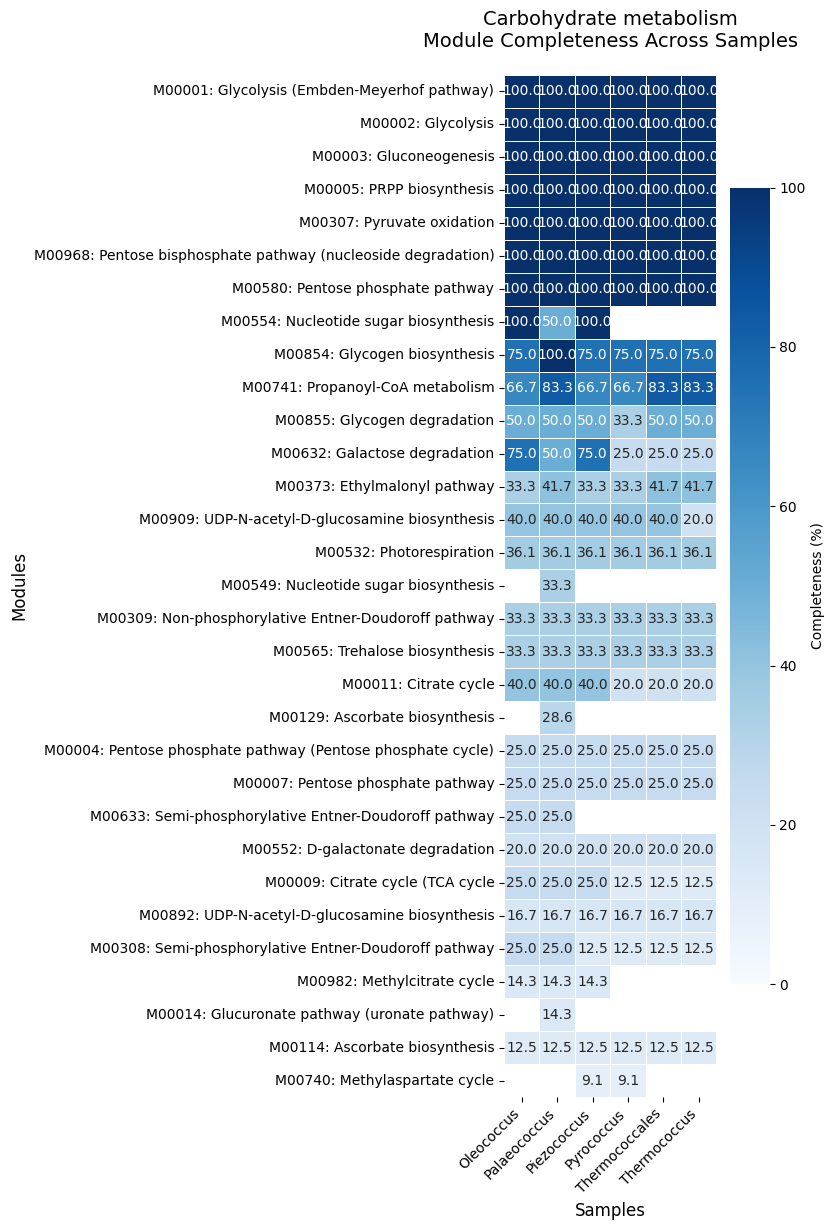

✅ Carbohydrate metabolism heatmap created!

Creating heatmap 2/10: Metabolism of cofactors and vitamins
Dimensions: 31 modules × 6 samples
Figure size: 8.0 × 12.4 inches
Statistics:
  Mean completeness: 41.4%
  Modules with 100% completeness: 17
  Modules with 0% completeness: 0


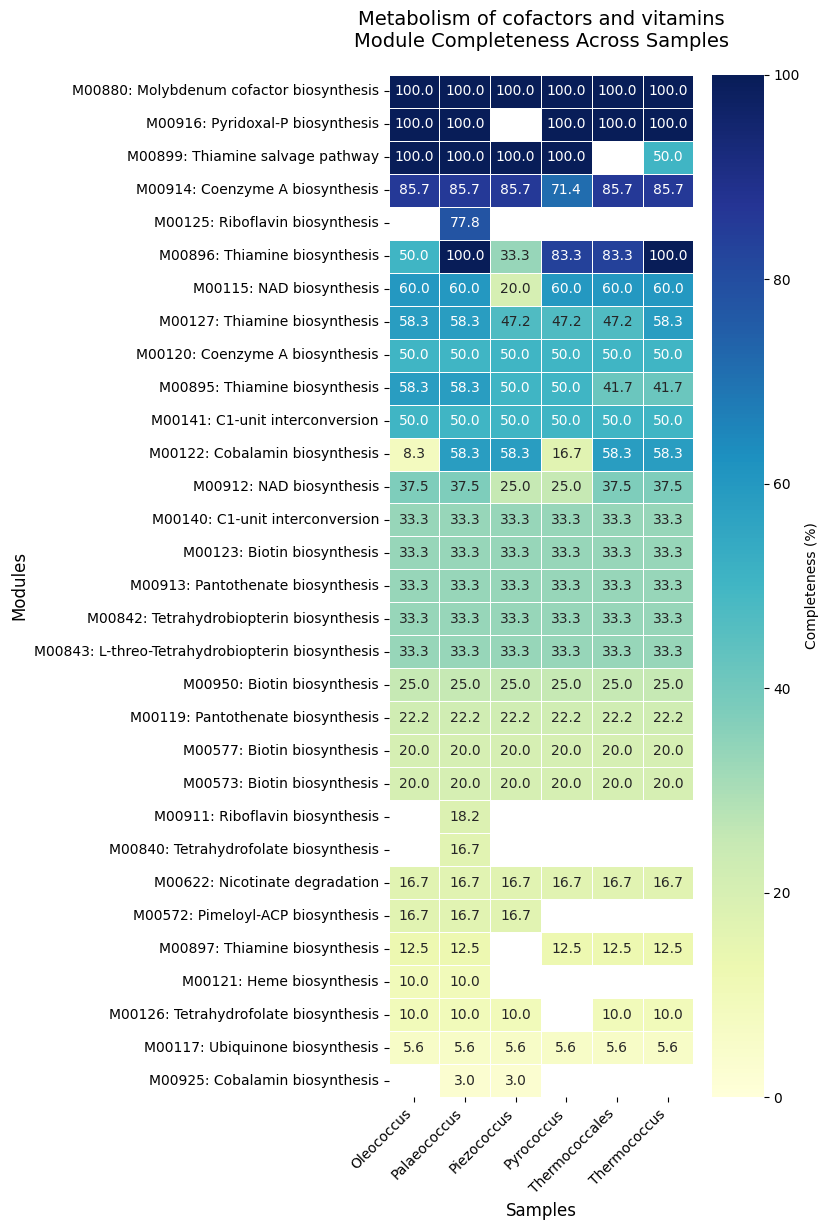

✅ Metabolism of cofactors and vitamins heatmap created!

Creating heatmap 3/10: Amino acid metabolism
Dimensions: 34 modules × 6 samples
Figure size: 8.0 × 13.6 inches
Statistics:
  Mean completeness: 42.9%
  Modules with 100% completeness: 12
  Modules with 0% completeness: 0


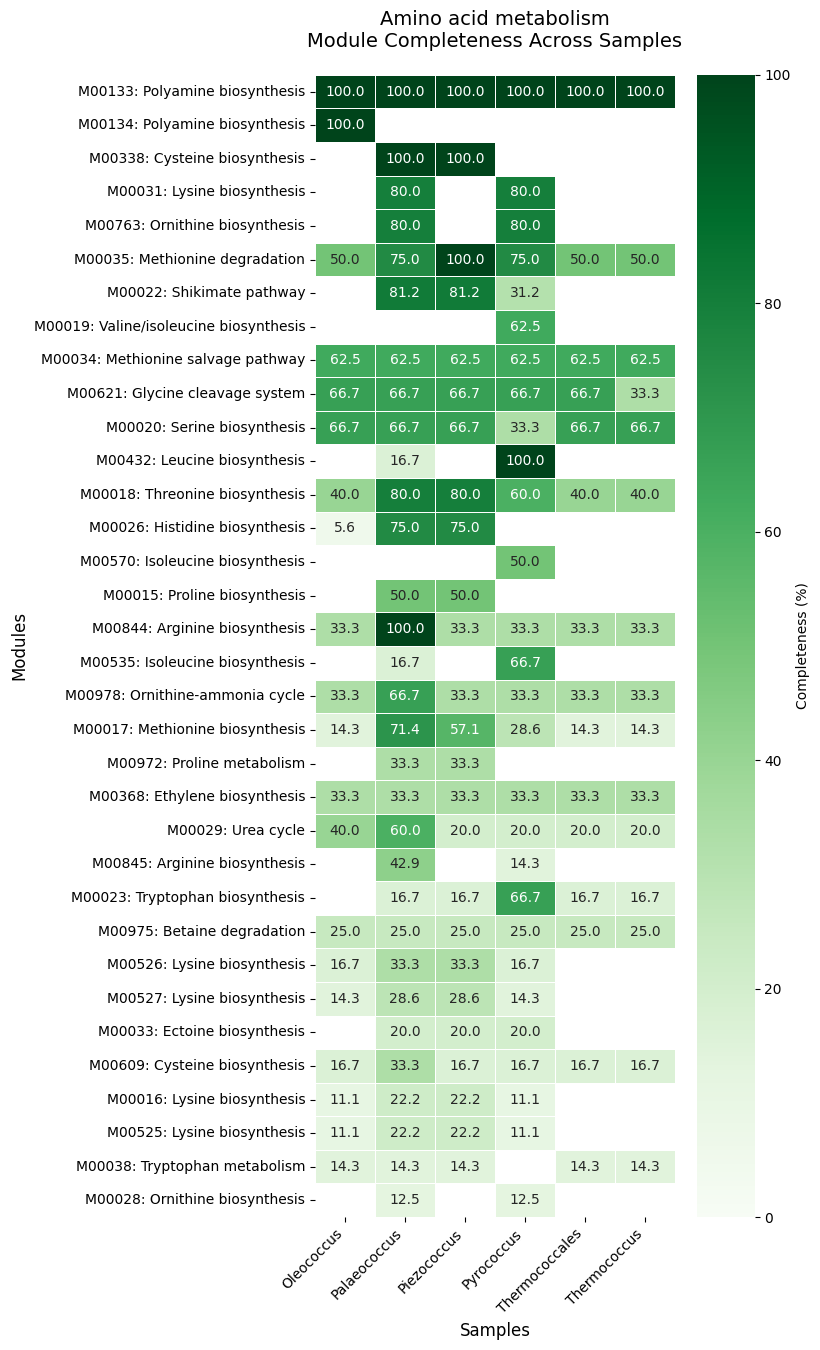

✅ Amino acid metabolism heatmap created!

Creating heatmap 4/10: Energy metabolism
Dimensions: 24 modules × 6 samples
Figure size: 8.0 × 9.6 inches
Statistics:
  Mean completeness: 35.7%
  Modules with 100% completeness: 11
  Modules with 0% completeness: 0


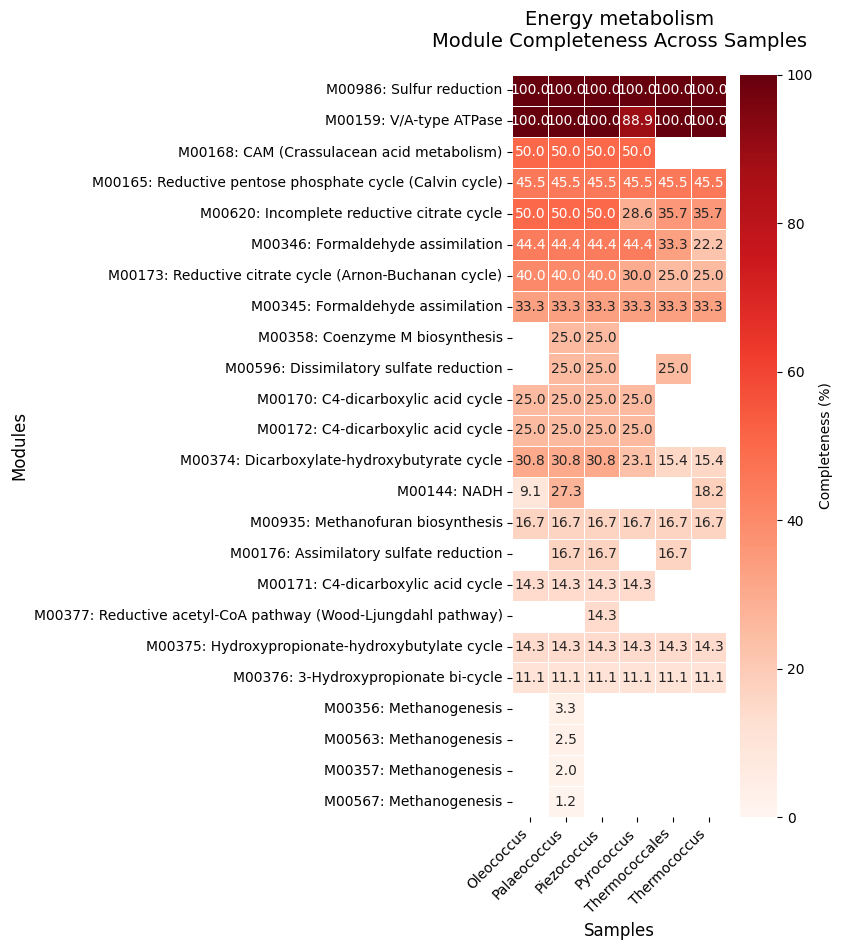

✅ Energy metabolism heatmap created!

Creating heatmap 5/10: Nucleotide metabolism
Dimensions: 9 modules × 6 samples
Figure size: 8.0 × 4.0 inches
Statistics:
  Mean completeness: 69.0%
  Modules with 100% completeness: 14
  Modules with 0% completeness: 0


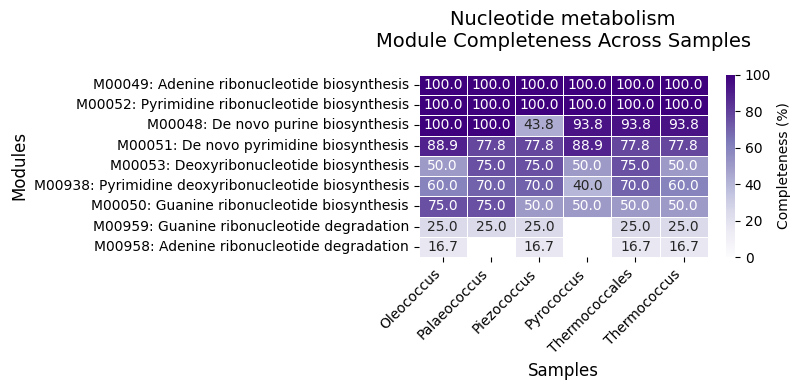

✅ Nucleotide metabolism heatmap created!

Creating heatmap 6/10: Biosynthesis of terpenoids and polyketides
Dimensions: 8 modules × 6 samples
Figure size: 8.0 × 4.0 inches
Statistics:
  Mean completeness: 47.2%
  Modules with 100% completeness: 3
  Modules with 0% completeness: 0


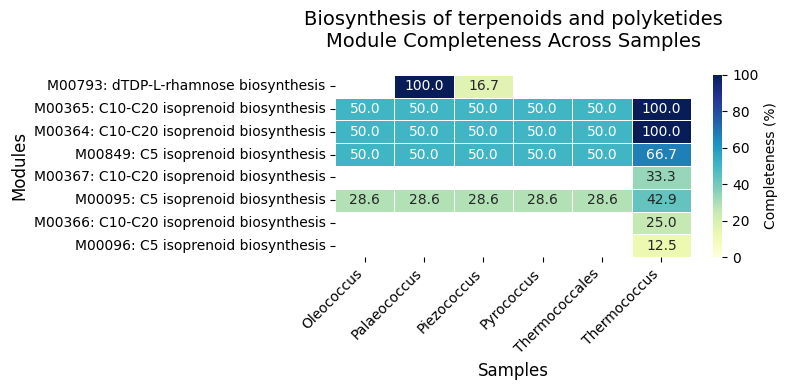

✅ Biosynthesis of terpenoids and polyketides heatmap created!

Creating heatmap 7/10: Lipid metabolism
Dimensions: 4 modules × 6 samples
Figure size: 8.0 × 4.0 inches
Statistics:
  Mean completeness: 46.1%
  Modules with 100% completeness: 2
  Modules with 0% completeness: 0


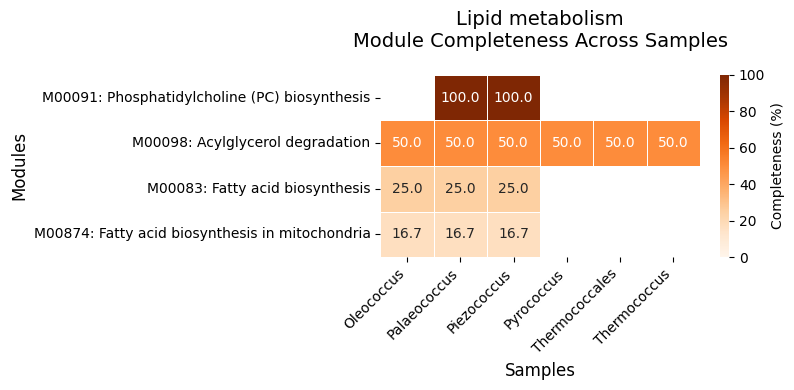

✅ Lipid metabolism heatmap created!

Creating heatmap 8/10: Biosynthesis of other secondary metabolites
Dimensions: 3 modules × 6 samples
Figure size: 8.0 × 4.0 inches
Statistics:
  Mean completeness: 22.0%
  Modules with 100% completeness: 0
  Modules with 0% completeness: 0


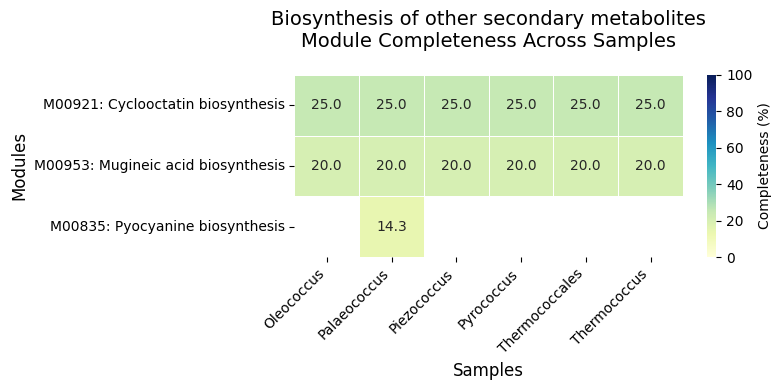

✅ Biosynthesis of other secondary metabolites heatmap created!

Creating heatmap 9/10: Glycan metabolism
Dimensions: 3 modules × 5 samples
Figure size: 8.0 × 4.0 inches
Statistics:
  Mean completeness: 12.1%
  Modules with 100% completeness: 0
  Modules with 0% completeness: 0


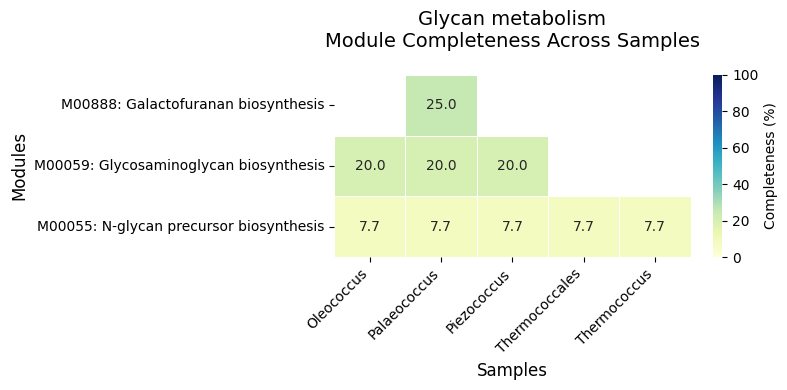

✅ Glycan metabolism heatmap created!

Creating heatmap 10/10: Gene set
Dimensions: 1 modules × 6 samples
Figure size: 8.0 × 4.0 inches
Statistics:
  Mean completeness: 33.3%
  Modules with 100% completeness: 0
  Modules with 0% completeness: 0


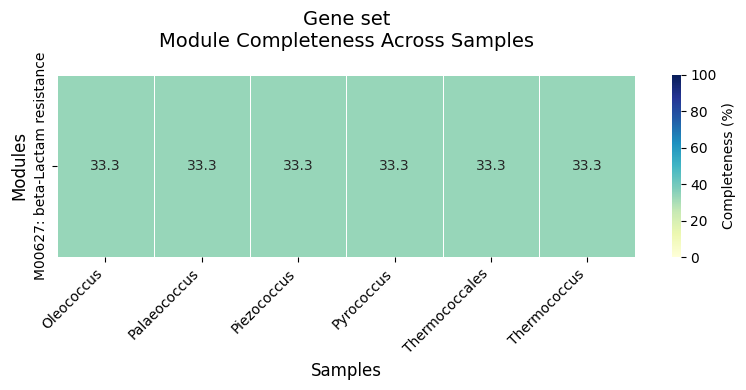

✅ Gene set heatmap created!

🎨 All 10 metabolism-specific heatmaps created successfully!


In [51]:
if 'metabolism_pivots' in locals():
    print("Creating metabolism-specific heatmaps...")
    
    # Define colors for different metabolism types
    metabolism_colors = {
        'Carbohydrate metabolism': 'Blues',
        'Amino acid metabolism': 'Greens', 
        'Energy metabolism': 'Reds',
        'Nucleotide metabolism': 'Purples',
        'Lipid metabolism': 'Oranges',
        'Vitamin and cofactor metabolism': 'viridis',
        'Metabolism of other amino acids': 'plasma',
        'Xenobiotics biodegradation and metabolism': 'YlOrBr'
    }
    
    # Create heatmaps for each metabolism type
    fig_count = 0
    
    for met_type, pivot_data in metabolism_pivots.items():
        fig_count += 1
        print(f"\n{'='*60}")
        print(f"Creating heatmap {fig_count}/{len(metabolism_pivots)}: {met_type}")
        print(f"{'='*60}")
        
        # Calculate figure size based on number of modules
        n_modules = len(pivot_data)
        n_samples = len(pivot_data.columns)
        
        fig_width = max(8, n_samples * 0.8)  # Minimum 8 inches, scale with samples
        fig_height = max(4, n_modules * 0.4)  # Minimum 4 inches, scale with modules
        
        print(f"Dimensions: {n_modules} modules × {n_samples} samples")
        print(f"Figure size: {fig_width:.1f} × {fig_height:.1f} inches")
        
        # Create the figure
        plt.figure(figsize=(fig_width, fig_height))
        
        # Choose colormap
        colormap = metabolism_colors.get(met_type, 'YlGnBu')
        
        # Create heatmap
        sns.heatmap(
            pivot_data,
            annot=True,
            fmt=".1f",
            cmap=colormap,
            linewidths=0.5,
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'Completeness (%)'}
        )
        
        # Add title with metabolism type
        plt.title(f"{met_type}\nModule Completeness Across Samples", 
                 fontsize=14, pad=20)
        plt.ylabel("Modules", fontsize=12)
        plt.xlabel("Samples", fontsize=12)
        
        # Rotate x-axis labels
        plt.xticks(rotation=45, ha='right')
        
        # Adjust layout
        plt.tight_layout()
        
        # Show statistics
        print(f"Statistics:")
        print(f"  Mean completeness: {pivot_data.mean().mean():.1f}%")
        print(f"  Modules with 100% completeness: {(pivot_data == 100).sum().sum()}")
        print(f"  Modules with 0% completeness: {(pivot_data == 0).sum().sum()}")
        
        plt.show()
        
        print(f"✅ {met_type} heatmap created!")
    
    print(f"\n🎨 All {len(metabolism_pivots)} metabolism-specific heatmaps created successfully!")
    
else:
    print("❌ metabolism_pivots not available. Run previous cells first.")

In [52]:
if 'metabolism_pivots' in locals():
    print("Saving metabolism-specific heatmaps to files...")
    
    # Create a directory for metabolism-specific plots
    metabolism_dir = "metabolism_heatmaps"
    if not os.path.exists(metabolism_dir):
        os.makedirs(metabolism_dir)
        print(f"Created directory: {metabolism_dir}")
    
    saved_files = []
    
    for met_type, pivot_data in metabolism_pivots.items():
        print(f"\nSaving {met_type} heatmap...")
        
        # Create safe filename
        safe_filename = met_type.replace(' ', '_').replace('/', '_').lower()
        image_path = os.path.join(metabolism_dir, f"{safe_filename}_heatmap.png")
        
        # Calculate figure size
        n_modules = len(pivot_data)
        n_samples = len(pivot_data.columns)
        fig_width = max(8, n_samples * 0.8)
        fig_height = max(4, n_modules * 0.4)
        
        # Create and save heatmap
        plt.figure(figsize=(fig_width, fig_height))
        
        colormap = metabolism_colors.get(met_type, 'YlGnBu')
        
        sns.heatmap(
            pivot_data,
            annot=True,
            fmt=".1f",
            cmap=colormap,
            linewidths=0.5,
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'Completeness (%)'}
        )
        
        plt.title(f"{met_type}\nModule Completeness Across Samples", 
                 fontsize=14, pad=20)
        plt.ylabel("Modules", fontsize=12)
        plt.xlabel("Samples", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        # Save with high DPI
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        plt.close()  # Close to free memory
        
        # Verify file was saved
        if os.path.exists(image_path):
            file_size = os.path.getsize(image_path)
            print(f"  ✅ Saved: {image_path} ({file_size:,} bytes)")
            saved_files.append(image_path)
        else:
            print(f"  ❌ Failed to save: {image_path}")
        
        # Also save the data as CSV
        csv_path = os.path.join(metabolism_dir, f"{safe_filename}_data.csv")
        pivot_data.to_csv(csv_path)
        
        if os.path.exists(csv_path):
            csv_size = os.path.getsize(csv_path)
            print(f"  ✅ Data saved: {csv_path} ({csv_size:,} bytes)")
    
    # Final summary
    print(f"\n{'='*60}")
    print(f"METABOLISM HEATMAPS SUMMARY")
    print(f"{'='*60}")
    print(f"📁 Output directory: {metabolism_dir}")
    print(f"🎨 Heatmaps created: {len(saved_files)}")
    print(f"💾 Data files saved: {len(metabolism_pivots)}")
    
    print(f"\nSaved heatmaps:")
    for i, file_path in enumerate(saved_files, 1):
        filename = os.path.basename(file_path)
        print(f"  {i}. {filename}")
    
    print(f"\n✅ All metabolism-specific heatmaps saved successfully!")
    
else:
    print("❌ metabolism_pivots not available. Run previous cells first.")

Saving metabolism-specific heatmaps to files...
Created directory: metabolism_heatmaps

Saving Carbohydrate metabolism heatmap...
  ✅ Saved: metabolism_heatmaps\carbohydrate_metabolism_heatmap.png (708,202 bytes)
  ✅ Data saved: metabolism_heatmaps\carbohydrate_metabolism_data.csv (2,147 bytes)

Saving Metabolism of cofactors and vitamins heatmap...
  ✅ Saved: metabolism_heatmaps\metabolism_of_cofactors_and_vitamins_heatmap.png (666,877 bytes)
  ✅ Data saved: metabolism_heatmaps\metabolism_of_cofactors_and_vitamins_data.csv (2,018 bytes)

Saving Amino acid metabolism heatmap...
  ✅ Saved: metabolism_heatmaps\amino_acid_metabolism_heatmap.png (713,387 bytes)
  ✅ Data saved: metabolism_heatmaps\amino_acid_metabolism_data.csv (1,969 bytes)

Saving Energy metabolism heatmap...
  ✅ Saved: metabolism_heatmaps\energy_metabolism_heatmap.png (548,683 bytes)
  ✅ Data saved: metabolism_heatmaps\energy_metabolism_data.csv (1,574 bytes)

Saving Nucleotide metabolism heatmap...
  ✅ Saved: metabolism

## 11. Summary
You now have both the original comprehensive heatmap and separate heatmaps for each metabolism type!

### What was created:
1. **Original comprehensive heatmap** - All modules together
2. **Metabolism-specific heatmaps** - Separate heatmaps for:
   - Carbohydrate metabolism
   - Amino acid metabolism  
   - Energy metabolism
   - Nucleotide metabolism
   - And other metabolism types found in your data

### Output files:
- `module_completeness_heatmap.png` - Original comprehensive heatmap
- `heatmap_data.csv` - Original data
- `metabolism_heatmaps/` directory containing:
  - Individual PNG files for each metabolism type
  - Individual CSV data files for each metabolism type

Each metabolism-specific heatmap uses a different color scheme to help distinguish between the different types of metabolic processes!